In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob, os, re

# ---------- CONFIG: set your CSV folder path ----------
RESULTS_DIR = '/content/'   # <-- CHANGE THIS

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# ---------- 1. Load all CSVs with flexible naming ----------
def parse_filename(filename):
    """
    Expected patterns:
      mnist_none_seed0.csv
      mni_stl_no_warmup_seed0.csv
      fashion_mnist_linear_warmup_seed5.csv
      fashion_mnist_cosine_warmup_seed9.csv
    Return (dataset, scheduler, seed) or None.
    """
    base = os.path.basename(filename).replace('.csv', '')
    # Possible formats: 'fashion_mnist_cosine_warmup_seed10', 'mnist_no_warmup_seed0'
    parts = base.split('_')
    if 'fashion' in base:
        dataset = 'fmnist'
        # find scheduler and seed
        # pattern: fashion_mnist_SCHEDULER_warmup_seedSEED, or fashion_mnist_SCHEDULER_seedSEED
        # remove 'fashion_mnist' part
        rest = base.replace('fashion_mnist_', '')
    elif base.startswith('mnist') or base.startswith('mni'):
        dataset = 'mnist'
        rest = base.replace('mnist_', '').replace('mni_stl_', '')
    else:
        return None

    # rest is e.g. "linear_warmup_seed3", "no_warmup_seed0", "cosine_warmup_seed9", "none_seed0"
    # split by '_seed'
    if '_seed' in rest:
        sched_part, seed_str = rest.rsplit('_seed', 1)
        seed = int(seed_str)
        # scheduler: map common names
        sched_map = {
            'no_warmup': 'none',
            'linear_warmup': 'linear',
            'cosine_warmup': 'cosine',
            'none': 'none',
            'linear': 'linear',
            'cosine': 'cosine'
        }
        scheduler = sched_map.get(sched_part, sched_part)  # fallback
        return dataset, scheduler, seed
    else:
        # try other splits
        return None

files = glob.glob(os.path.join(RESULTS_DIR, '*.csv'))
df_list = []
for f in files:
    info = parse_filename(f)
    if info is None:
        print(f'Skipping unrecognised file: {f}')
        continue
    dataset, scheduler, seed = info
    temp = pd.read_csv(f)
    temp['dataset'] = dataset
    temp['scheduler'] = scheduler
    temp['seed'] = seed
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
print(f'Loaded {len(files)} files, {df.shape[0]} rows.')
print('Unique datasets:', df['dataset'].unique())
print('Unique schedulers:', df['scheduler'].unique())

Loaded 60 files, 1800 rows.
Unique datasets: ['mnist' 'fmnist']
Unique schedulers: ['cosine' 'linear' 'none']


In [ ]:
# Extract last epoch for each run
last_epoch = df.groupby(['dataset','scheduler','seed']).last().reset_index()

# Summary table
summary = last_epoch.groupby(['dataset','scheduler'])['val_acc'].agg(['mean','std']).round(3)
print('Mean ± Std of final val_acc (last epoch):')
print(summary)

# Pairwise Welch t‑tests
from itertools import combinations
results_rows = []
for dataset in ['mnist', 'fmnist']:
    subset = last_epoch[last_epoch['dataset'] == dataset]
    for s1, s2 in combinations(['none','linear','cosine'], 2):
        d1 = subset[subset['scheduler']==s1]['val_acc']
        d2 = subset[subset['scheduler']==s2]['val_acc']
        t_stat, p_val = stats.ttest_ind(d1, d2, equal_var=False)
        results_rows.append({
            'Dataset': dataset.upper(),
            'Comparison': f'{s1} vs {s2}',
            't-statistic': f'{t_stat:.3f}',
            'p-value': f'{p_val:.4f}',
            'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No'
        })

ttest_df = pd.DataFrame(results_rows)
print('\nPairwise Welch t‑tests:')
print(ttest_df.to_string(index=False))

Mean ± Std of final val_acc (last epoch):
                    mean    std
dataset scheduler              
fmnist  cosine     0.891  0.005
        linear     0.892  0.005
        none       0.891  0.004
mnist   cosine     0.977  0.001
        linear     0.977  0.001
        none       0.977  0.001

Pairwise Welch t‑tests:
Dataset       Comparison t-statistic p-value Significant (α=0.05)
  MNIST   none vs linear       1.087  0.2924                   No
  MNIST   none vs cosine       0.841  0.4112                   No
  MNIST linear vs cosine      -0.338  0.7395                   No
 FMNIST   none vs linear      -0.178  0.8606                   No
 FMNIST   none vs cosine       0.358  0.7251                   No
 FMNIST linear vs cosine       0.489  0.6309                   No


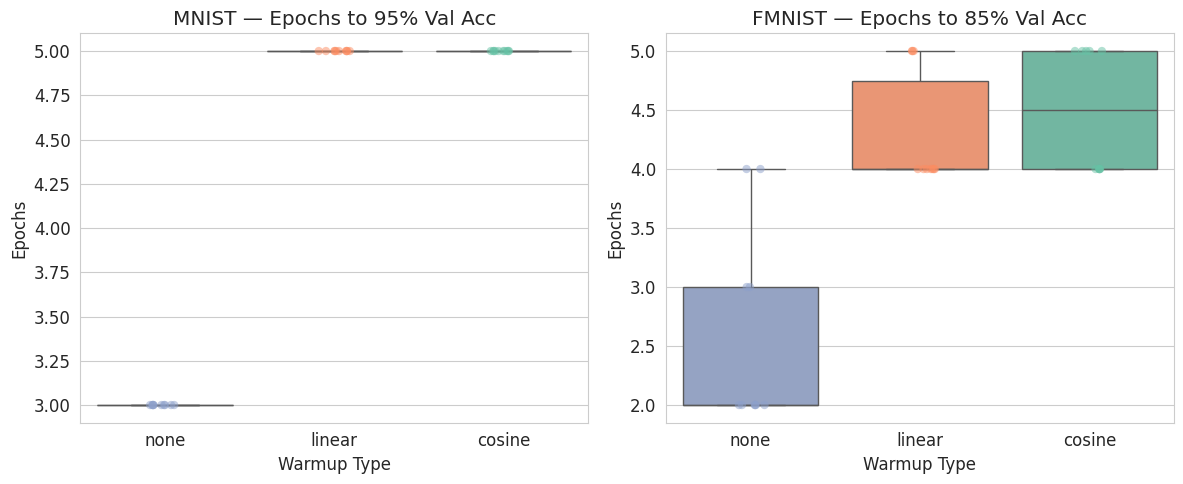

In [ ]:
thresholds = {'mnist': 0.95, 'fmnist': 0.85}   # FRACTIONS, not percent
first_reach = []
for (dataset, scheduler, seed), group in df.groupby(['dataset','scheduler','seed']):
    thresh = thresholds[dataset]
    reached = group[group['val_acc'] >= thresh]
    if len(reached) == 0:
        first_epoch = 31
    else:
        first_epoch = reached['epoch'].min()
    first_reach.append({'dataset': dataset, 'scheduler': scheduler, 'seed': seed, 'epoch_to_thresh': first_epoch})
first_df = pd.DataFrame(first_reach)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, dataset in enumerate(['mnist', 'fmnist']):
    ax = axes[i]
    subset = first_df[first_df['dataset'] == dataset]
    sns.boxplot(x='scheduler', y='epoch_to_thresh', data=subset, order=['none','linear','cosine'],
                hue='scheduler', palette='Set2', legend=False, ax=ax)
    sns.stripplot(x='scheduler', y='epoch_to_thresh', data=subset, order=['none','linear','cosine'],
                  hue='scheduler', palette='Set2', legend=False, color='black', alpha=0.5, ax=ax, size=6)
    ax.set_title(f'{dataset.upper()} — Epochs to {thresholds[dataset]*100:.0f}% Val Acc')
    ax.set_ylabel('Epochs')
    ax.set_xlabel('Warmup Type')
plt.tight_layout()
plt.savefig('figure1_epochs_to_threshold.pdf', bbox_inches='tight')
plt.show()

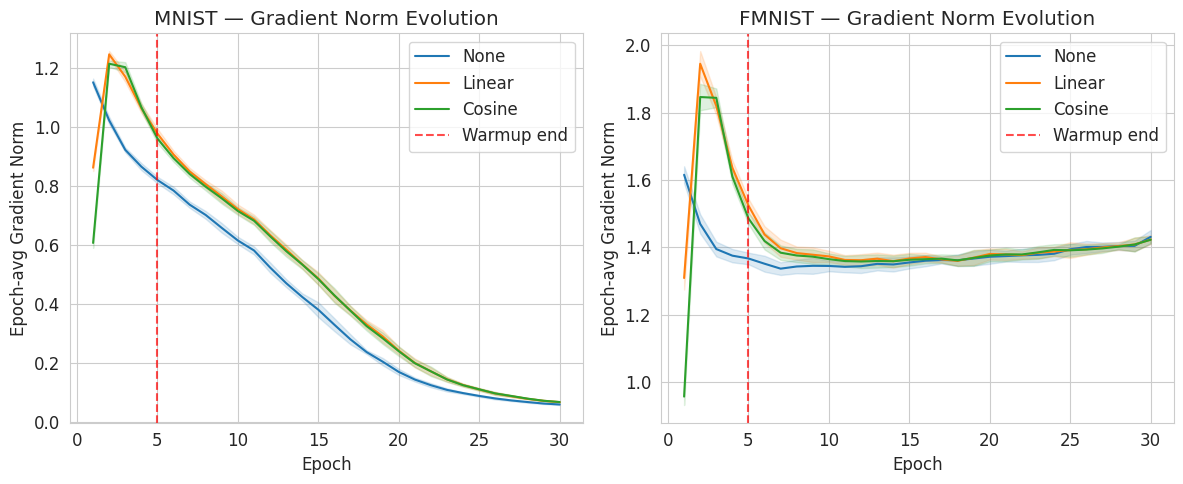

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'none': 'tab:blue', 'linear': 'tab:orange', 'cosine': 'tab:green'}
for i, dataset in enumerate(['mnist', 'fmnist']):
    ax = axes[i]
    for sched in ['none','linear','cosine']:
        subset = df[(df['dataset']==dataset) & (df['scheduler']==sched)]
        means = subset.groupby('epoch')['grad_norm_epoch_avg'].mean()
        stds  = subset.groupby('epoch')['grad_norm_epoch_avg'].std()
        epochs = means.index
        ax.plot(epochs, means, color=colors[sched], label=sched.replace('_',' ').title())
        ax.fill_between(epochs, means-stds, means+stds, color=colors[sched], alpha=0.15)
    ax.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Warmup end')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Epoch‑avg Gradient Norm')
    ax.set_title(f'{dataset.upper()} — Gradient Norm Evolution')
    ax.legend()
plt.tight_layout()
plt.savefig('figure2_gradient_norm.pdf', bbox_inches='tight')
plt.show()

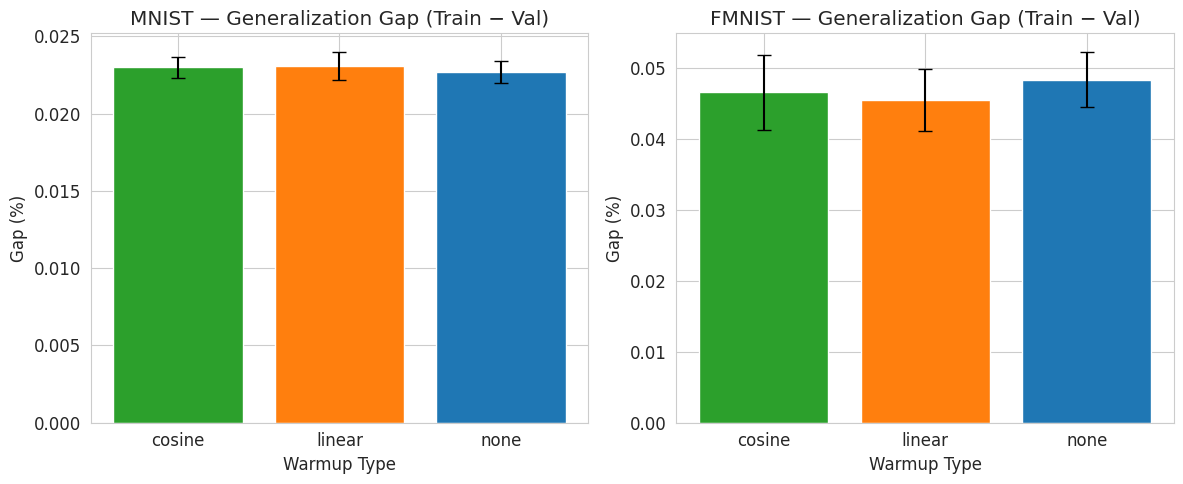

In [ ]:
# Compute generalization gap if missing
if 'generalization_gap' not in last_epoch.columns:
    last_epoch['generalization_gap'] = last_epoch['train_acc'] - last_epoch['val_acc']

gap_summary = last_epoch.groupby(['dataset','scheduler'])['generalization_gap'].agg(['mean','std']).round(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, dataset in enumerate(['mnist', 'fmnist']):
    ax = axes[i]
    subset = gap_summary.loc[dataset]
    ax.bar(subset.index, subset['mean'], yerr=subset['std'], capsize=5,
           color=[colors[s] for s in subset.index])
    ax.set_title(f'{dataset.upper()} — Generalization Gap (Train − Val)')
    ax.set_ylabel('Gap (%)')
    ax.set_xlabel('Warmup Type')
plt.tight_layout()
plt.savefig('figure3_generalization_gap.pdf', bbox_inches='tight')
plt.show()